In [2]:
def select_neighbours(size, center, dim_axis_0, dim_axis_1):
    """
    Selects the elements within a kernel centered at the center element.

    Parameters
    ----------
    size : int
        The size of the kernel.
    center : int
        The number of the element with which the kernel center aligns. Should be calculated by:
        index_0 * dim_axis_1 + index_1.
    dim_axis_0 : int
        The number of elements in axis 0.
    dim_axis_1 : int
        The number of elements in axis 1.

    Returns
    -------
    list<int>
        A list of numbers that indicate the neighbouring pixels of the center element (the center element is included).
    """
    half = size // 2
    col_start = max(center % dim_axis_1 - half, 0)
    col_end = min(center % dim_axis_1 + half + 1, dim_axis_1)
    row_start = max(center // dim_axis_1 - half, 0)
    row_end = min(center // dim_axis_1 + half + 1, dim_axis_0)
    return [i * dim_axis_1 + j for i in range(row_start, row_end) for j in range(col_start, col_end)]


[  9   9  22  37  66 118 136 145 162 162 173 202 216 225 248 248 268 268
 284 301] [  9   9  22  37  66 118 136 145 162 162 173 202 216 225 248 248 268 268
 284 301]
20821 20821
103106.0
61310 61310 41796.0
[  6  12  27  30  35 100 100 116 160 165 177 236 251 272 281 287 313 320
 338 349] [  6  12  27  30  35 100 100 116 160 165 177 236 251 272 281 287 313 320
 338 349]
449 449
42541.0
41641 41641 900.0


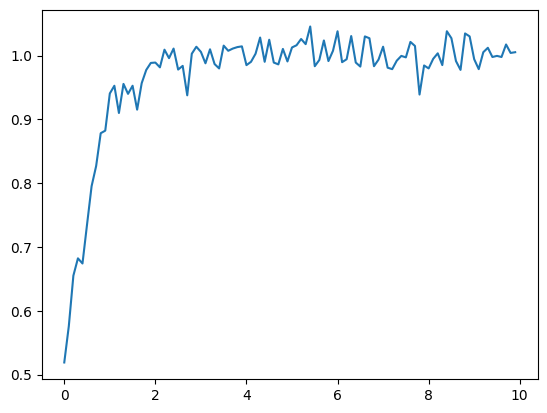

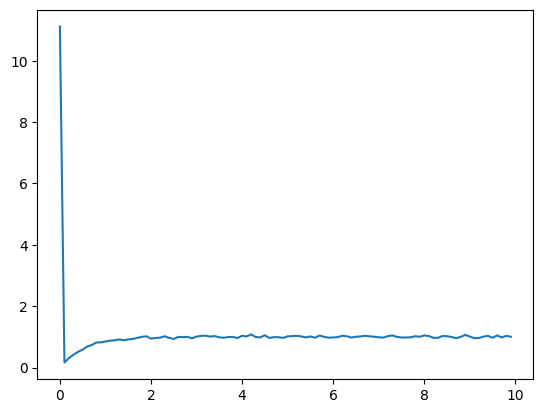

(array([584., 585., 653., 610., 613., 608., 634., 629., 625., 648., 607.,
        588., 671., 617., 582., 648., 653., 597., 579., 595., 596., 575.,
        592., 647., 574., 603., 609., 635., 604., 581., 616., 635., 576.,
        588., 599., 631., 628., 603., 616., 598., 629., 635., 607., 636.,
        623., 600., 604., 601., 628., 647., 650., 580., 569., 661., 604.,
        639., 628., 621., 585., 632., 607., 595., 599., 642., 608., 642.,
        631., 616., 634., 583., 646., 610., 617., 570., 632., 639., 617.,
        631., 587., 610., 631., 611., 568., 585., 631., 631., 621., 602.,
        567., 600., 574., 630., 588., 633., 650., 602., 608., 612., 619.,
        620.]),
 array([9.35592704e-01, 1.00091073e+03, 2.00088588e+03, 3.00086102e+03,
        4.00083616e+03, 5.00081130e+03, 6.00078644e+03, 7.00076158e+03,
        8.00073672e+03, 9.00071187e+03, 1.00006870e+04, 1.10006621e+04,
        1.20006373e+04, 1.30006124e+04, 1.40005876e+04, 1.50005627e+04,
        1.60005379e+04, 1.7000

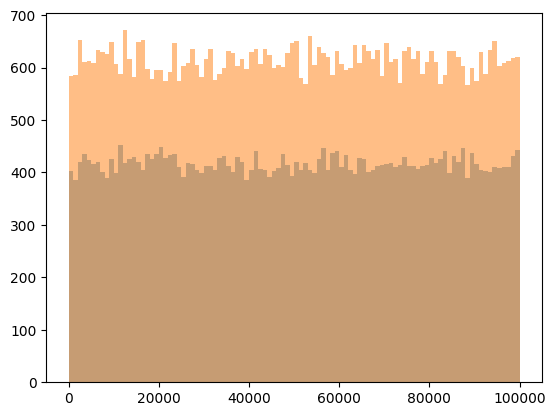

In [34]:
import numpy as np

def count_consecutive_duplicates(numbers):
    """
    Count the number of times consecutive elements in a list are identical.
    
    Args:
        numbers (list): A list of numbers
        
    Returns:
        int: The count of consecutive duplicate elements
    """
    # Handle edge case of empty list or single element list
    if len(numbers) <= 1:
        return 0
    
    count = 0
    
    # Iterate through the list comparing adjacent elements
    for i in range(len(numbers) - 1):
        if numbers[i] == numbers[i + 1]:
            count += 1
            
    return count

def count_pairs(array1, array2):
    """
    Counts the number of element pairs that occur in both arrays. Example: [1, 4, 4] and [1, 3, 4, 5] counts 1 pair of
    ones and 2 pairs of fours, so the function returns 3.

    Parameters
    ----------
    array1 : np.array()
        Array of N elements, sorted in ascending order.
    array2 : np.array()
        Array of M elements, sorted in ascending order.

    Returns
    -------
    count : int
        The number of pairs of elements that was counted in the input arrays.
    """
    N = len(array1)
    M = len(array2)

    count = 0
    i = 0
    j = 0
    while i < N and j < M:
        val1 = array1[i]
        val2 = array2[j]

        if val1 < val2:
            i += 1
        elif val2 < val1:
            j += 1
        else:
            # Found a pair!
            count_array1 = 1
            while (i + 1) < N and array1[i + 1] == val1:
                count_array1 += 1
                i += 1
            count_array2 = 1
            while (j + 1) < M and array2[j + 1] == val2:
                count_array2 += 1
                j += 1

            count += count_array1 * count_array2
            i += 1
            j += 1
    return count
def sparse_convolution(indices1, indices2, nr_steps, offset=0):
    """
    Calculates a convolution of indices1 with indices2 for a number of steps. The input arrays contain indices of delta
    peaks in the discrete input signal. Because the signal is sparse, the fastest way to compute the convolution is by
    doing a convolution by comparing the indices of the data to each other.

    Parameters
    ----------
    indices1 : np.array()
        Data indices of a discrete signal sorted in ascending order.
    indices2 : np.array()
        Data indices of a discrete signal sorted in ascending order. To be correlated with indices1.
    nr_steps : int
        The number of steps the signal should be shifted across itself to calculate the convolution.
    offset : int
        Optional offset for the number of lags. For example, if nr_steps is 100 and start is 30, the convolution will
        calculate the convolution for lag 30 to lag 129. Default is 0.

    Returns
    -------
    pairs : np.array()
        A (nr_steps,) array containing the number of element pairs when indices2 is shifted over indices1 with a certain
        lag.
    """
    pairs = np.zeros(nr_steps)
    for m in range(nr_steps):
        pairs[m] = count_pairs(indices1, indices2 + offset + m)
    return pairs

def coherence(signal1, signal2, interval, bin_size, nr_steps, offset=0, normalize=True, auto_correlation=False):
    """
    Calculates the second-order quantum coherence of the measured photons in a certain interval on different pixels.

    Parameters
    ----------
    signal1, signal2 : np.array()
        A signal consisting of hits in a certain interval.
    interval : float
        The time interval in which the photons were measured.
    bin_size : float
        The size of the sub-intervals that split up the data in order to create a discrete time signal.
    nr_steps : int
        The number of steps across which the coherence is calculated.
    offset : int
        Indicates from which number of steps on the coherence should be calculated. Default is 0, so that the coherence
        is calculated for steps [0, nr_steps).
    normalize : bool
        If True, the coherence is normalized. If False, the values that are returned are the photon counts per lag,
        corrected for bias. Default is True.
    auto_correlation : bool
        If True, a signal is correlated with itself. The found number of pairs then needs to be adjusted so that photons
        do not form a pair with themselves.

    Returns
    -------
    correlation : np.array()
        (nr_steps,) array containing the photon pairs per shift.
    lag : np.array()
        (nr_steps,) array indicating the amount of delay in the signal shift.
    """
    # Calculate the bin indices of the photon hitting times.
    photon_indices1 = np.floor(signal1 / bin_size).astype(np.int64)
    photon_indices2 = np.floor(signal2 / bin_size).astype(np.int64)
    print(photon_indices1[:20], photon_indices2[:20])
    print(count_consecutive_duplicates(photon_indices1), count_consecutive_duplicates(photon_indices2))
    photon_pairs = sparse_convolution(photon_indices1, photon_indices2, nr_steps, offset)

    print(photon_pairs[0])
    if auto_correlation and offset == 0:
        photon_pairs[0] -= len(signal1)  # subtract the photons that form a pair with themselves
    print(len(signal1), len(signal2), photon_pairs[0])
    # Correct for bias. This is necessary if you use an offset or use multipe (>1) steps.
    m = int(interval / bin_size) # Number of bins in the interval.
    bias = np.arange(m - offset, m - offset - nr_steps, -1)
    correlation = photon_pairs * (m / bias)

    # Normalize in order to obtain the correlation from the photon pair count.
    if normalize and len(signal1) != 0 and len(signal2) != 0:
        correlation = correlation * m / (len(signal1) * len(signal2))
        # m / (len(signal1) * len(signal2)) is the 'probability' of two photons over the whole interval landing in the same bin.

    bins = np.arange(offset, nr_steps + offset) * bin_size
    return correlation, bins



import matplotlib.pyplot as plt
#load data
data25 = np.load('detected_photons_2_5.npy')
data55 = np.load('detected_photons_5_5.npy')

#calculate autocoherences
coh55 = coherence(data55[:,1], data55[:,1], 100000, 0.1, 100, auto_correlation=True)
coh25 = coherence(data25[:,1], data25[:,1], 100000, 0.1, 100, auto_correlation=True)
#plot coherence
plt.plot(coh25[1], coh25[0], label='2.5')
plt.show()
plt.plot(coh55[1], coh55[0], label='5.5')
plt.show()
#plot distribution of second column in data

plt.hist(data25[:,1], bins=100, alpha=0.5, label='2.5')
plt.hist(data55[:,1], bins=100, alpha=0.5, label='5.5')

Number of intervals: 5000
Mean interval: 1.955 (theoretical: 1.000)
Std deviation: 1.364 (theoretical: 1.000)
Min interval: 0.016
Max interval: 9.183


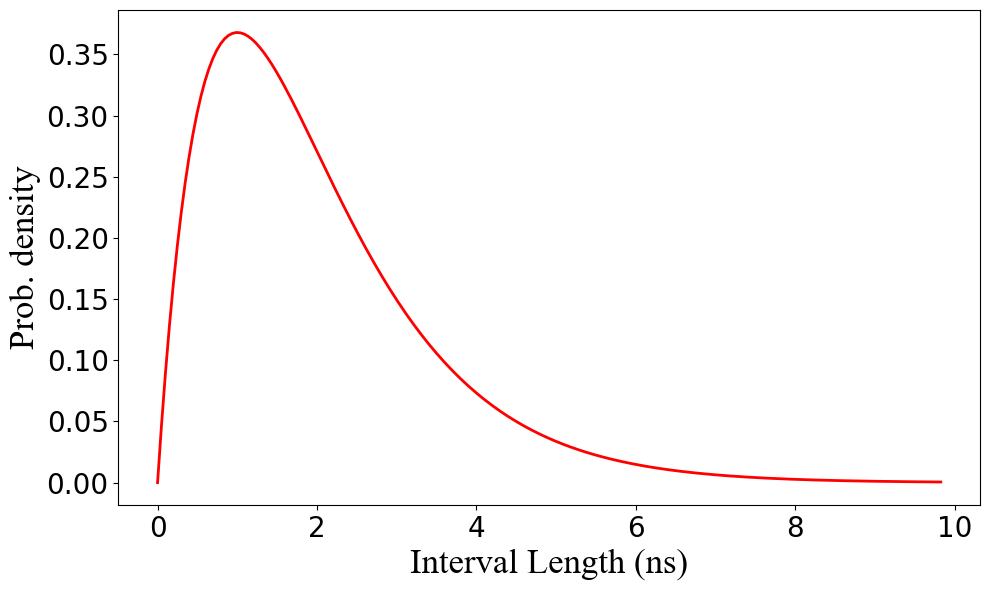

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gamma

font = {'family': 'Times New Roman',
        'weight': 'normal',
        'size': 25}


# Set random seed for reproducibility
np.random.seed(42)

# Parameters
k_ex = 1.0
k_em = 1.0
n_events = 5000

# Generate inter-arrival times (exponentially distributed)
intervals = np.random.exponential(1/k_ex, n_events) + np.random.exponential(1/k_em, n_events)

X = np.random.exponential(1/k_ex, n_events)
Y = np.random.exponential(1/k_em, n_events)
Z = X + Y
# Generate cumulative arrival times
arrival_times = np.cumsum(intervals)

# Plot histogram of intervals
plt.figure(figsize=(10, 6))
#plt.hist(intervals, bins=100, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# Overlay theoretical exponential distribution
x = np.linspace(0, max(intervals), 100)
theoretical1 = gamma.pdf(x, a=2, scale=k_ex + k_em)
theoretical2 = (k_ex+k_em)**2 *x * np.exp(-(k_ex+k_em) * x)

def hypoexp_pdf(z, a, b):
    if abs(a - b) < 1e-10:  # Equal rates case (Gamma)
        return a**2 * z * np.exp(-a * z)
    else:  # Different rates case
        return (a * b / (b - a)) * (np.exp(-a * z) - np.exp(-b * z))

# Plot theoretical curve
z_theory = np.linspace(0, max(Z), 200)
theoretical = [hypoexp_pdf(z, k_ex, k_em) for z in z_theory]
plt.plot(z_theory, theoretical, 'r-', linewidth=2, 
         label=f'Theoretical (a={k_ex}, b={k_em})')

#plt.plot(x, theoretical1, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')
#plt.plot(x, 5*theoretical1*theoretical2, 'r-', linewidth=2, label=f'Theoretical Gam({k_ex+k_em})')


plt.xlabel('Interval Length (ns)', fontdict=font)
plt.ylabel('Prob. density', fontdict=font)
#increase textsize of plot
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

#times new roman font



#label text size

#plt.title('Distribution of Inter-arrival Times in Poisson Process')
#plt.legend()
#plt.grid(False, alpha=0.3)

# Print statistics
print(f"Number of intervals: {len(intervals)}")
print(f"Mean interval: {np.mean(intervals):.3f} (theoretical: {1/lambda_rate:.3f})")
print(f"Std deviation: {np.std(intervals):.3f} (theoretical: {1/lambda_rate:.3f})")
print(f"Min interval: {np.min(intervals):.3f}")
print(f"Max interval: {np.max(intervals):.3f}")

plt.tight_layout()
plt.show()

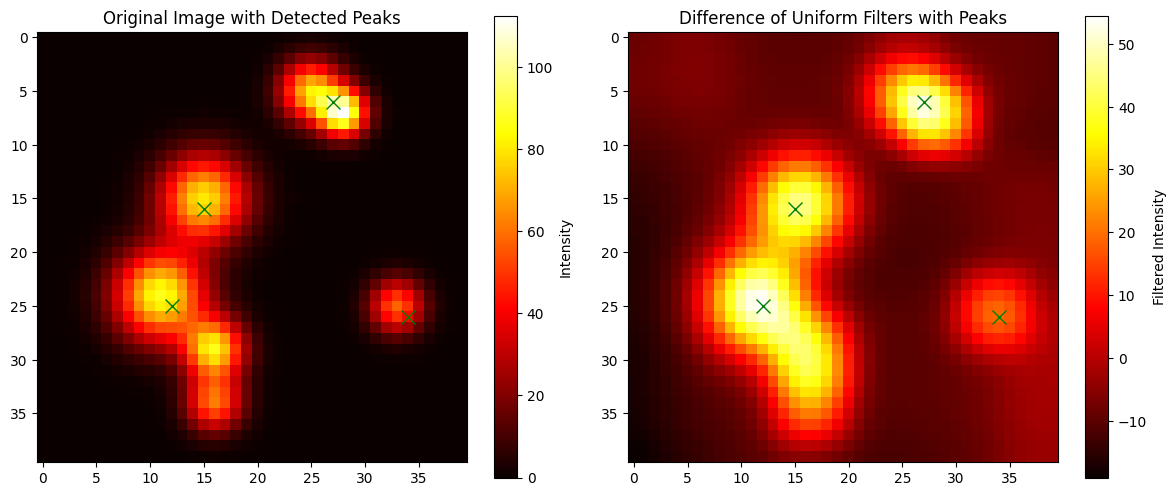

Found 4 peaks at positions:
Peak 1: (y=25, x=12), Intensity: 78.3
Peak 2: (y=6, x=27), Intensity: 104.0
Peak 3: (y=16, x=15), Intensity: 75.9
Peak 4: (y=26, x=34), Intensity: 41.4


In [58]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

def find_peaks_dou(image, psf_size=3, min_distance=None, threshold_abs=None, 
                   num_peaks=np.inf, plot_results=True):
    """
    Find peaks in an image using Difference of Uniform Filters (DoU) approach.
    
    Parameters:
    -----------
    image : 2D numpy array
        The input image in which to find peaks
    psf_size : int, optional
        Approximate size of the Point Spread Function (should be odd), default=3
    min_distance : int, optional
        Minimum distance between peaks in pixels, default=psf_size
    threshold_abs : float, optional
        Minimum intensity threshold for peaks, default=0.05*max(filtered_image)
    num_peaks : int, optional
        Maximum number of peaks to return, default=np.inf (all peaks)
    plot_results : bool, optional
        Whether to plot the results, default=True
        
    Returns:
    --------
    peak_positions : ndarray
        Array of (y, x) coordinates of peaks found
    filtered_image : ndarray
        The DoU filtered image used for peak detection
    """
    # Ensure psf_size is odd
    if psf_size % 2 == 0:
        psf_size += 1
        
    # Calculate filter sizes
    unif1_sz = 2 * psf_size  # First uniform filter size
    unif2_sz = 6 * unif1_sz   # Second uniform filter size
    
    # Set default min_distance if not provided
    if min_distance is None:
        min_distance = psf_size
    
    # Apply uniform filters
    # The uniform filter replaces each pixel with the average of a box of size unif_sz
    filtered1 = ndimage.uniform_filter(image, size=unif1_sz)
    filtered2 = ndimage.uniform_filter(image, size=unif2_sz)
    
    # Compute the Difference of Uniform filters
    filtered_image = filtered1 - filtered2
    
    # Set default threshold if not provided
    if threshold_abs is None:
        threshold_abs = 0.05 * np.max(filtered_image)
    
    # Find local maxima (peaks)
    peak_positions = peak_local_max(
        filtered_image, 
        min_distance=min_distance,
        threshold_abs=threshold_abs,
        num_peaks=num_peaks
    )
    
    # Plot results if requested
    if plot_results:
        plt.figure(figsize=(12, 5))
        
        # Original image
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='hot')
        plt.colorbar(label='Intensity')
        plt.plot(peak_positions[:, 1], peak_positions[:, 0], 'gx', markersize=10)
        plt.title('Original Image with Detected Peaks')
        
        # Filtered image
        plt.subplot(1, 2, 2)
        plt.imshow(filtered_image, cmap='hot')
        plt.colorbar(label='Filtered Intensity')
        plt.plot(peak_positions[:, 1], peak_positions[:, 0], 'gx', markersize=10)
        plt.title('Difference of Uniform Filters with Peaks')
        
        plt.tight_layout()
        plt.show()
    
    return peak_positions, filtered_image

# Example usage on a synthetic test image
def create_test_image(size=40, num_peaks=5, peak_intensity=100, noise_level=5, seed=42):
    """
    Create a test image with random peaks for testing.
    """
    np.random.seed(seed)
    img = np.zeros((size, size))
    
    # Add random peaks
    for _ in range(num_peaks):
        x = np.random.randint(5, size-5)
        y = np.random.randint(5, size-5)
        sigma = np.random.uniform(1.5, 3.0)
        height = np.random.uniform(0.5, 1.0) * peak_intensity
        
        y_grid, x_grid = np.mgrid[0:size, 0:size]
        dist = np.sqrt((x_grid - x)**2 + (y_grid - y)**2)
        img += height * np.exp(-(dist**2) / (2 * sigma**2))
    
    # Add noise
    #img += np.random.normal(0, noise_level, img.shape)
    #img = np.maximum(img, 0)  # Ensure no negative values
    
    return img

test_img = create_test_image(size=40, num_peaks=7, peak_intensity=100, noise_level=20)
    
# Find peaks
peaks, filtered = find_peaks_dou(
    test_img,
    psf_size=2,
    min_distance=5,
    threshold_abs=None,
    plot_results=True
)

print(f"Found {len(peaks)} peaks at positions:")
for i, (y, x) in enumerate(peaks):
    print(f"Peak {i+1}: (y={y}, x={x}), Intensity: {test_img[y, x]:.1f}")

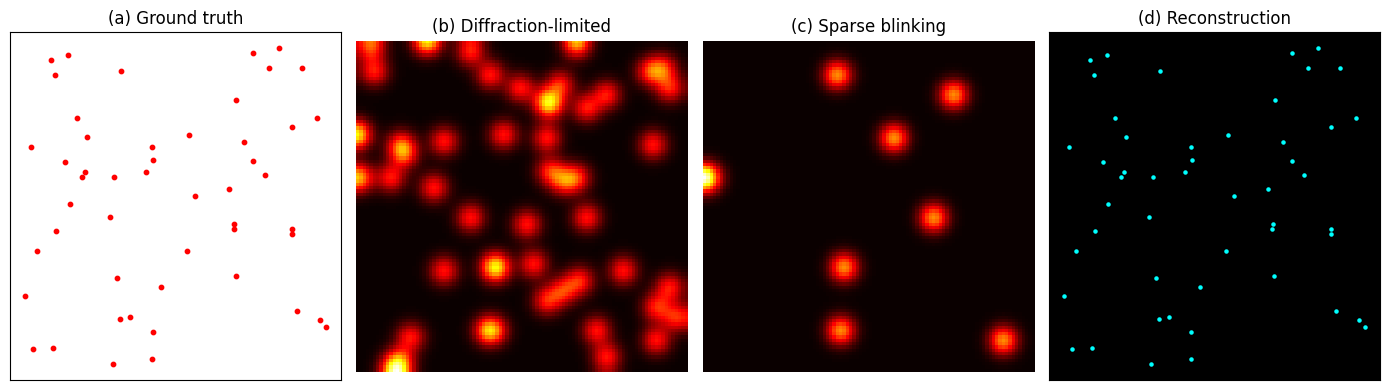

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

def plot_smlm_schematic(n_emitters=50, img_size=100, blur_sigma=3, n_sparse=8, seed=1):
    """
    Create a 4-panel schematic showing the principle of SMLM:
    (a) Ground truth emitters
    (b) Diffraction-limited image
    (c) Sparse blinking frame
    (d) Reconstructed image (localized emitters)
    """
    np.random.seed(seed)
    
    # Random ground truth emitter positions
    gt_x, gt_y = np.random.rand(n_emitters), np.random.rand(n_emitters)
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    
    # (a) Ground truth
    axes[0].scatter(gt_x, gt_y, c='red', s=10)
    axes[0].set_title("(a) Ground truth")
    axes[0].set_xticks([]); axes[0].set_yticks([])
    
    # (b) Diffraction-limited image
    image = np.zeros((img_size, img_size))
    coords = (gt_x * img_size, gt_y * img_size)
    for x, y in zip(*coords):
        image[int(x), int(y)] += 1
    blurred = gaussian_filter(image, sigma=blur_sigma)
    axes[1].imshow(blurred, cmap="hot")
    axes[1].set_title("(b) Diffraction-limited")
    axes[1].axis("off")
    
    # (c) Sparse blinking
    image_sparse = np.zeros((img_size, img_size))
    # subset seed = 1
    np.random.seed(2)
    subset = np.random.choice(range(n_emitters), n_sparse, replace=False)
    for idx in subset:
        x, y = int(gt_x[idx]*img_size), int(gt_y[idx]*img_size)
        image_sparse[x, y] += 1
    sparse_blurred = gaussian_filter(image_sparse, sigma=blur_sigma)
    axes[2].imshow(sparse_blurred, cmap="hot")
    axes[2].set_title("(c) Sparse blinking")
    axes[2].axis("off")
    
    # (d) Reconstructed image
    axes[3].scatter(gt_x, gt_y, c='cyan', s=5)
    axes[3].set_facecolor("black")
    axes[3].set_title("(d) Reconstruction")
    axes[3].set_xticks([]); axes[3].set_yticks([])
    
    plt.tight_layout()
    plt.show()

# Example usage
plot_smlm_schematic()


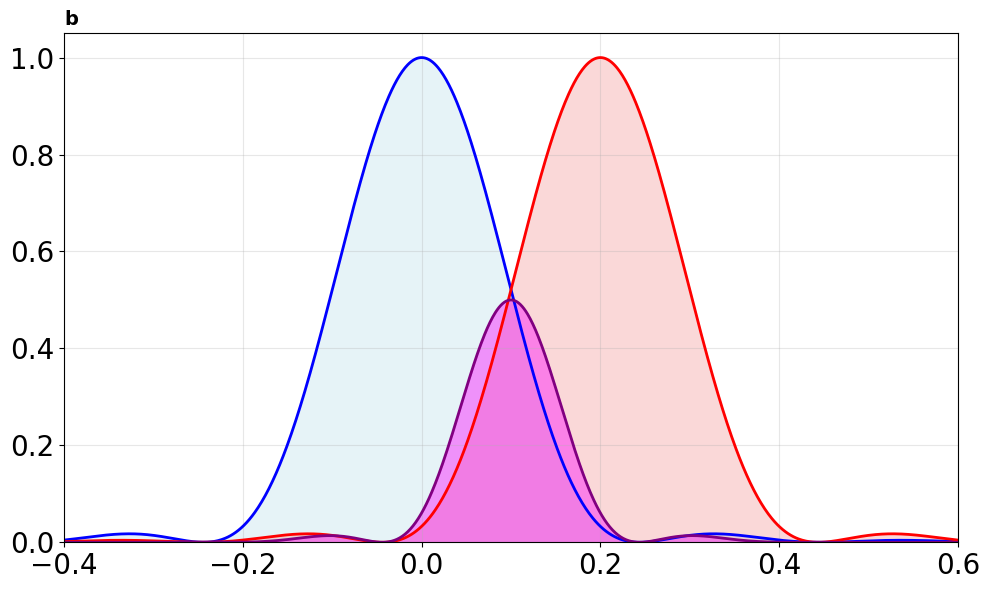

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import j1  # First-order Bessel function
# Define position array
position = np.linspace(-0.4, 0.6, 1000)

# Parameters for the Gaussian PSFs
# Left PSF (excitation intensity)
center1 = 0
sigma1 = 0.2
amplitude1 = 1.0

# Right PSF (detection PSF)
center2 = 0.2
sigma2 = 0.2
amplitude2 = 1.0

# Create the Airy disk function
def airy_disk(x, center, width, amplitude):
    # Shift x to center the Airy disk
    x_shifted = (x - center) / width
    
    # Handle the case where x_shifted = 0 (center of Airy disk)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Airy disk pattern: [2*J1(pi*r)/(pi*r)]^2
        airy = np.where(x_shifted == 0, 1.0, (2 * j1(np.pi * np.abs(x_shifted)) / (np.pi * np.abs(x_shifted)))**2)
    
    return amplitude * airy

# Create the Gaussian functions
def gaussian(x, center, sigma, amplitude):
    return amplitude * np.exp(-0.5 * ((x - center) / sigma) ** 2)

# Calculate the individual PSFs
excitation_psf = airy_disk(position, center1, sigma1, amplitude1)
detection_psf = airy_disk(position, center2, sigma2, amplitude2)

# Calculate the combined signal (product of the two PSFs)
combined_signal = excitation_psf * detection_psf

# Normalize the combined signal for better visualization
combined_signal = combined_signal / np.max(combined_signal) * 0.5

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the excitation PSF (blue)
plt.fill_between(position, 0, excitation_psf, alpha=0.3, color='lightblue', label='Excitation intensity')
plt.plot(position, excitation_psf, color='blue', linewidth=2)

# Plot the detection PSF (orange/red)
plt.fill_between(position, 0, detection_psf, alpha=0.3, color='lightcoral', label='Detection PSF')
plt.plot(position, detection_psf, color='red', linewidth=2)

# Plot the combined signal (green/olive)
plt.fill_between(position, 0, combined_signal, alpha=0.4, color='magenta')
plt.plot(position, combined_signal, color='purple', linewidth=2)

# Add labels for IISM and IrISM (approximated positions)
# plt.annotate('I_ISM', xy=(-0.05, 0.8), xytext=(-0.2, 0.8),
#              arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
#              fontsize=12, color='orange')

# plt.annotate('I_rISM', xy=(-0.05, 0.6), xytext=(-0.25, 0.6),
#              arrowprops=dict(arrowstyle='->', color='orange', lw=1.5),
#              fontsize=12, color='orange')

# Add s and s/2 labels for the combined signal
# Find the center and half-width of the combined signal
combined_center = position[np.argmax(combined_signal)]
combined_max = np.max(combined_signal)
half_max_indices = np.where(combined_signal >= combined_max/2)[0]
left_half_max = position[half_max_indices[0]]
right_half_max = position[half_max_indices[-1]]

# Add vertical lines and labels
#plt.axvline(combined_center, ymin=0, ymax=combined_max/1.0, color='gray', linestyle='--', alpha=0.7)
#plt.axvline(left_half_max, ymin=0, ymax=0.25, color='gray', linestyle='--', alpha=0.7)
#plt.axvline(right_half_max, ymin=0, ymax=0.25, color='gray', linestyle='--', alpha=0.7)

# Add s and s/2 annotations
#plt.annotate('s/2', xy=(left_half_max, 0.15), ha='center', fontsize=10)
#plt.annotate('s', xy=(combined_center, 0.1), ha='center', fontsize=10)

# Formatting
#plt.xlabel('Position', fontsize=25)
#plt.ylabel('Amplitude', fontsize=25)
plt.title('b', fontsize=14, fontweight='bold', loc='left')
plt.grid(True, alpha=0.3)
plt.xlim(-0.4, 0.6)
plt.ylim(0, 1.05)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# Add legend
#plt.legend(loc='upper right')

# Adjust layout and show
plt.tight_layout()
plt.show()

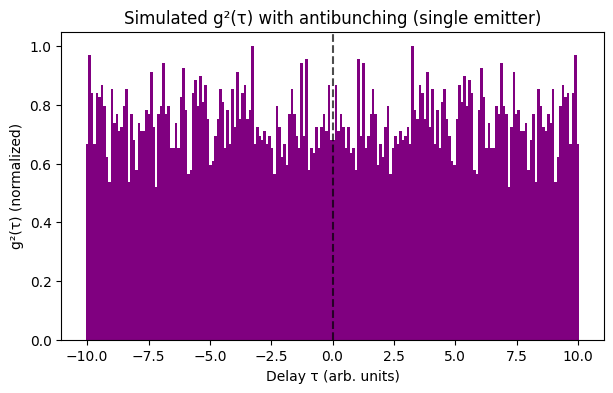

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Simulate photon arrival times for a single emitter with antibunching
np.random.seed(0)
n_events = 5000
mean_interval = 10.0
dead_time = 0.0

arrival_times = []
t = 0
for _ in range(n_events):
    wait = np.random.exponential(mean_interval) + dead_time
    t += wait
    arrival_times.append(t)
arrival_times = np.array(arrival_times)

# Define tau range and bin width for g2 calculation
n_bins = 200
tau_max = 10
taus = np.linspace(-tau_max, tau_max, n_bins)
bin_width = taus[1] - taus[0]
g2_counts = np.zeros_like(taus)

# Compute time differences between photons (positive only)
time_diffs = []
for i in range(len(arrival_times)):
    diffs = arrival_times[i+1:] - arrival_times[i]
    time_diffs.extend(diffs[diffs < tau_max])
time_diffs = np.array(time_diffs)

# Build histogram (positive taus)
hist, edges = np.histogram(time_diffs, bins=n_bins//2, range=(0, tau_max))
# Fill symmetric g2
g2_counts[n_bins//2:] = hist
g2_counts[:n_bins//2] = hist[::-1]

# Normalize
g2_norm = g2_counts / np.max(g2_counts)

# --- Plot ---
plt.figure(figsize=(7,4))
plt.bar(taus, g2_norm, width=bin_width, color="purple")
plt.xlabel("Delay τ (arb. units)")
plt.ylabel("g²(τ) (normalized)")
plt.title("Simulated g²(τ) with antibunching (single emitter)")
plt.axvline(0, color="k", linestyle="--", alpha=0.7)
plt.show()

(200, 200)
(100, 100)


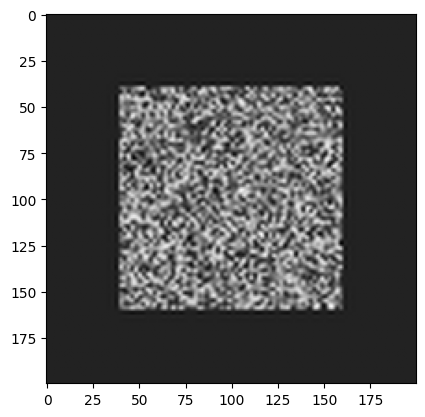

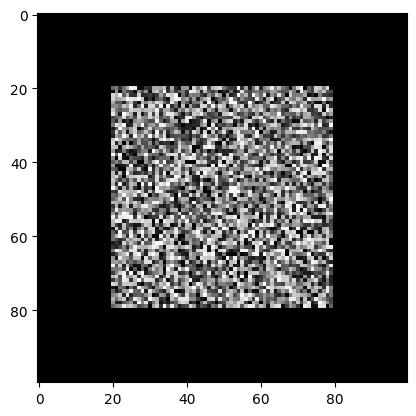

In [94]:

import numpy as np
from scipy.interpolate import RegularGridInterpolator

# create test image
sample_image = np.zeros((100, 100), dtype=np.uint16)
# load some online test image
sample_image[20:80, 20:80] = np.random.randint(0, 255, (60, 60), dtype=np.uint16)

def cubic_interpolation_rgi(image, scale_factor):
    """
    Performs cubic interpolation on a 2D image using RegularGridInterpolator to upscale it.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Input image as a 2D numpy array
    scale_factor : int or float
        Factor by which to scale the image (e.g., 2 for doubling the size)
    
    Returns:
    --------
    numpy.ndarray
        Upscaled image
    """
    # Get original dimensions
    height, width = image.shape
    
    # Calculate new dimensions
    new_height = int(height * scale_factor)
    new_width = int(width * scale_factor)
    
    # Create coordinate grids for the original image
    y_orig = np.arange(0, height)
    x_orig = np.arange(0, width)
    
    # Create the interpolation function
    # RegularGridInterpolator expects points in format (y, x)
    interp_func = RegularGridInterpolator(
        (y_orig, x_orig), 
        image, 
        method='cubic',
        bounds_error=False,
        fill_value=None  # Extrapolate values outside bounds
    )
    
    # Create meshgrid for the new coordinates
    y_new = np.linspace(0, height-1, new_height)
    x_new = np.linspace(0, width-1, new_width)
    Y_new, X_new = np.meshgrid(y_new, x_new, indexing='ij')
    
    # Stack coordinates for interpolation
    points = np.stack((Y_new.flatten(), X_new.flatten()), axis=-1)
    
    # Apply interpolation
    upscaled_flat = interp_func(points)
    
    # Reshape back to 2D
    upscaled_image = upscaled_flat.reshape((new_height, new_width))
    
    return upscaled_image


upscaled_image = cubic_interpolation_rgi(sample_image, 2)

import matplotlib.pyplot as plt
print(upscaled_image.shape)
plt.figure()
plt.imshow(upscaled_image, cmap='gray')
print(sample_image.shape)
plt.figure()
plt.imshow(sample_image, cmap='gray')

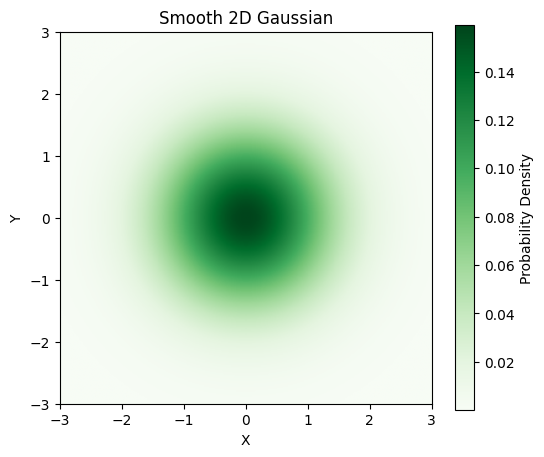

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Mean vector and covariance matrix
mu = [0, 0]
sigma = [[1, 0], [0, 1]]

# Create a finer grid
x = np.linspace(-3, 3, 300)
y = np.linspace(-3, 3, 300)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

# Create the Gaussian distribution
rv = multivariate_normal(mean=mu, cov=sigma)
Z = rv.pdf(pos)

# Plotting with imshow for smoothness
plt.figure(figsize=(6, 5), facecolor='white')
plt.imshow(Z, extent=(-3, 3, -3, 3), origin='lower', cmap='Greens')
plt.title('Smooth 2D Gaussian', color='black')
plt.xlabel('X', color='black')
plt.ylabel('Y', color='black')
plt.colorbar(label='Probability Density')
plt.grid(False)
plt.gca().set_facecolor('white')
plt.show()

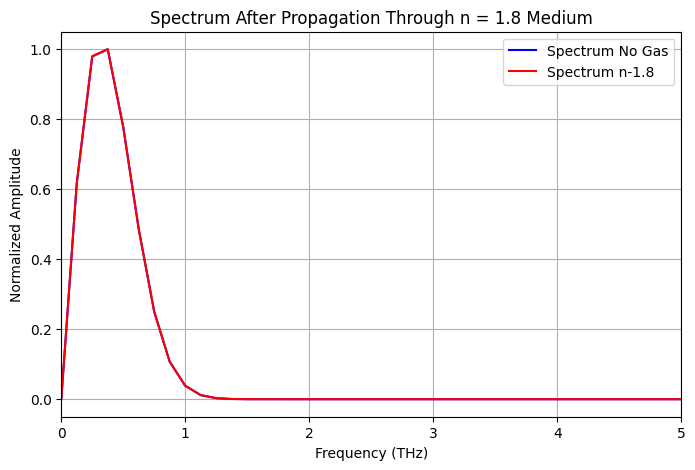

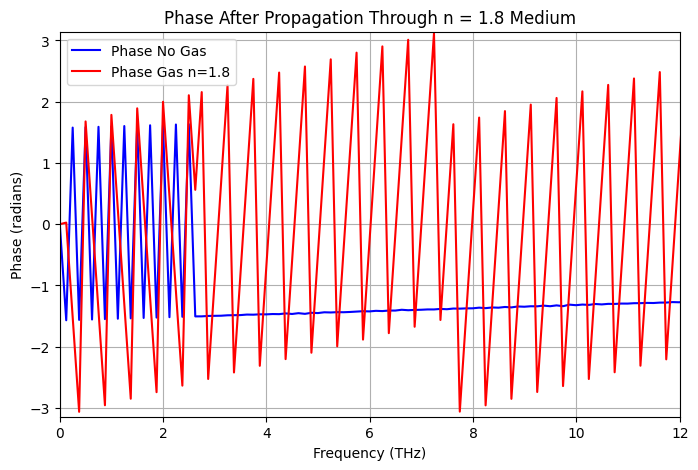

c:\Users\rensv\OneDrive - Delft University of Technology\MEP-RensPad\SPAD SMLM\spad-smlm\.venv\Lib\site-packages\matplotlib\cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


ValueError: x and y must have same first dimension, but have shapes (1000,) and (2000,)

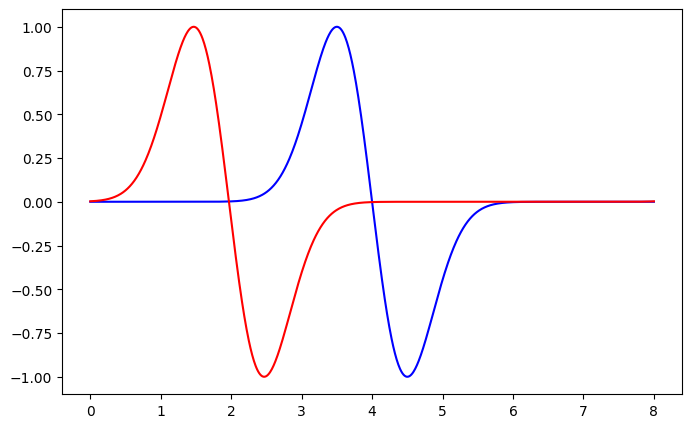

In [23]:
## TERAHERTZ ASSIGNMENT 4

import numpy as np
import matplotlib.pyplot as plt

# Given parameters
b = 4  # ps
sigma = 0.5  # ps
a = 1 / (sigma * np.sqrt(2 * np.pi))  # Normalization factor

# Time range for plotting
t = np.linspace(0, 8, 1000)  # Time in ps

# Gaussian current
f_t = a * np.exp(-((t - b) ** 2) / (2 * sigma**2))

# Electric field (proportional to derivative of current)
E_t = -(t - b) / sigma**2 * f_t

# Normalize for plotting convenience
E_t = E_t / np.max(np.abs(E_t))  # Normalize to peak value

# Compute the Fourier Transform of E(t)
E_f = np.fft.fft(E_t)  # FFT of the electric field
freqs = np.fft.fftfreq(len(t), d=(t[1] - t[0]))  # Frequency axis in THz

# Convert frequency to THz (since time was in ps)
freqs = freqs * 1e12 * 1e-12  # Convert from Hz to THz

# Shift the FFT for better visualization
E_f_shifted = np.fft.fftshift(E_f)
freqs_shifted = np.fft.fftshift(freqs)

# Compute amplitude spectrum
amplitude_spectrum = np.abs(E_f_shifted)

# Normalize amplitude for visualization
amplitude_spectrum /= np.max(amplitude_spectrum)

phase_spectrum = np.angle(E_f_shifted)
# Constants
d = 5e-3  # Chamber length in meters (5 mm)
c = 3e8  # Speed of light in m/s
n_fixed = 1.8  # Refractive index of the first gas

# Convert frequency axis to Hz for calculations
omega = 2 * np.pi * freqs_shifted * 1e12  # Convert THz to rad/s

# Compute phase shift due to fixed index medium
phase_shift_fixed = (2 * np.pi * n_fixed * d * freqs_shifted * 1e12) / c

# Apply phase shift in frequency domain
E_f_fixed = E_f_shifted * np.exp(-1j * phase_shift_fixed)

# Compute time-domain pulse after propagation
E_t_fixed = np.fft.ifft(np.fft.ifftshift(E_f_fixed)).real


####
# Parameters for the absorptive medium
epsilon_inf = np.sqrt(1.8)
omega_p = 0.5 * 2 * np.pi * 1e12  # Radial frequency corresponding to 0.5 THz
omega_r = 1.7 * 2 * np.pi * 1e12  # Radial frequency corresponding to 1.7 THz
gamma = 0.2 * np.pi * 1e12

# Angular frequencies
omega = 2 * np.pi * freqs_shifted * 1e12

# Complex permittivity
epsilon_r = epsilon_inf * (1 + omega_p**2 / (omega_r**2 - omega**2 - 1j * gamma * omega))

# Complex refractive index
n_complex = np.sqrt(epsilon_r)

# Propagation through the absorptive medium
# Calculate the propagation factor
propagation_factor = np.exp(-1j * omega * n_complex * d / c)

# Apply the propagation factor to the frequency components
E_f_absorbed = E_f * propagation_factor

# Inverse Fourier Transform to get the time domain pulse after absorption
E_t_absorbed = np.fft.ifft(np.concatenate([E_f_absorbed, np.conjugate(E_f_absorbed[::-1])]))



# Plot spectrum and phase after fixed-index medium
plt.figure(figsize=(8, 5))
plt.plot(freqs_shifted, amplitude_spectrum, color = 'b', label = "Spectrum No Gas")	
plt.plot(freqs_shifted, np.abs(E_f_fixed) / np.max(np.abs(E_f_fixed)), color='red', label="Spectrum n-1.8")
plt.xlabel("Frequency (THz)")
plt.ylabel("Normalized Amplitude")
plt.title("Spectrum After Propagation Through n = 1.8 Medium")
plt.xlim(0, 5)  # Show up to 5 THz
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(freqs_shifted, phase_spectrum, color='blue', label="Phase No Gas")
plt.plot(freqs_shifted, np.angle(E_f_fixed), color='red', label="Phase Gas n=1.8")
plt.xlabel("Frequency (THz)")
plt.ylabel("Phase (radians)")
plt.title("Phase After Propagation Through n = 1.8 Medium")
plt.xlim(0, 12)
plt.ylim(-np.pi, np.pi)
plt.grid()
plt.legend()
plt.show()

# Plot time-domain pulse after fixed-index medium
plt.figure(figsize=(8, 5))
plt.plot(t, E_t, color='b', label="Time-Domain Pulse No Gas")
plt.plot(t, E_t_fixed, color='r', label="Time-Domain Pulse Gas n-1.8")
plt.plot(t, E_t_absorbed, color='g', label="Time-Domain Pulse Absorptive Medium")
plt.xlabel("Time (ps)")
plt.ylabel("Electric Field E(t)")
plt.title("Time-Domain Pulse After n = 1.8 Medium")
plt.axhline(0, color='black', linewidth=0.5, linestyle="--")
plt.grid()
plt.legend()
plt.show()

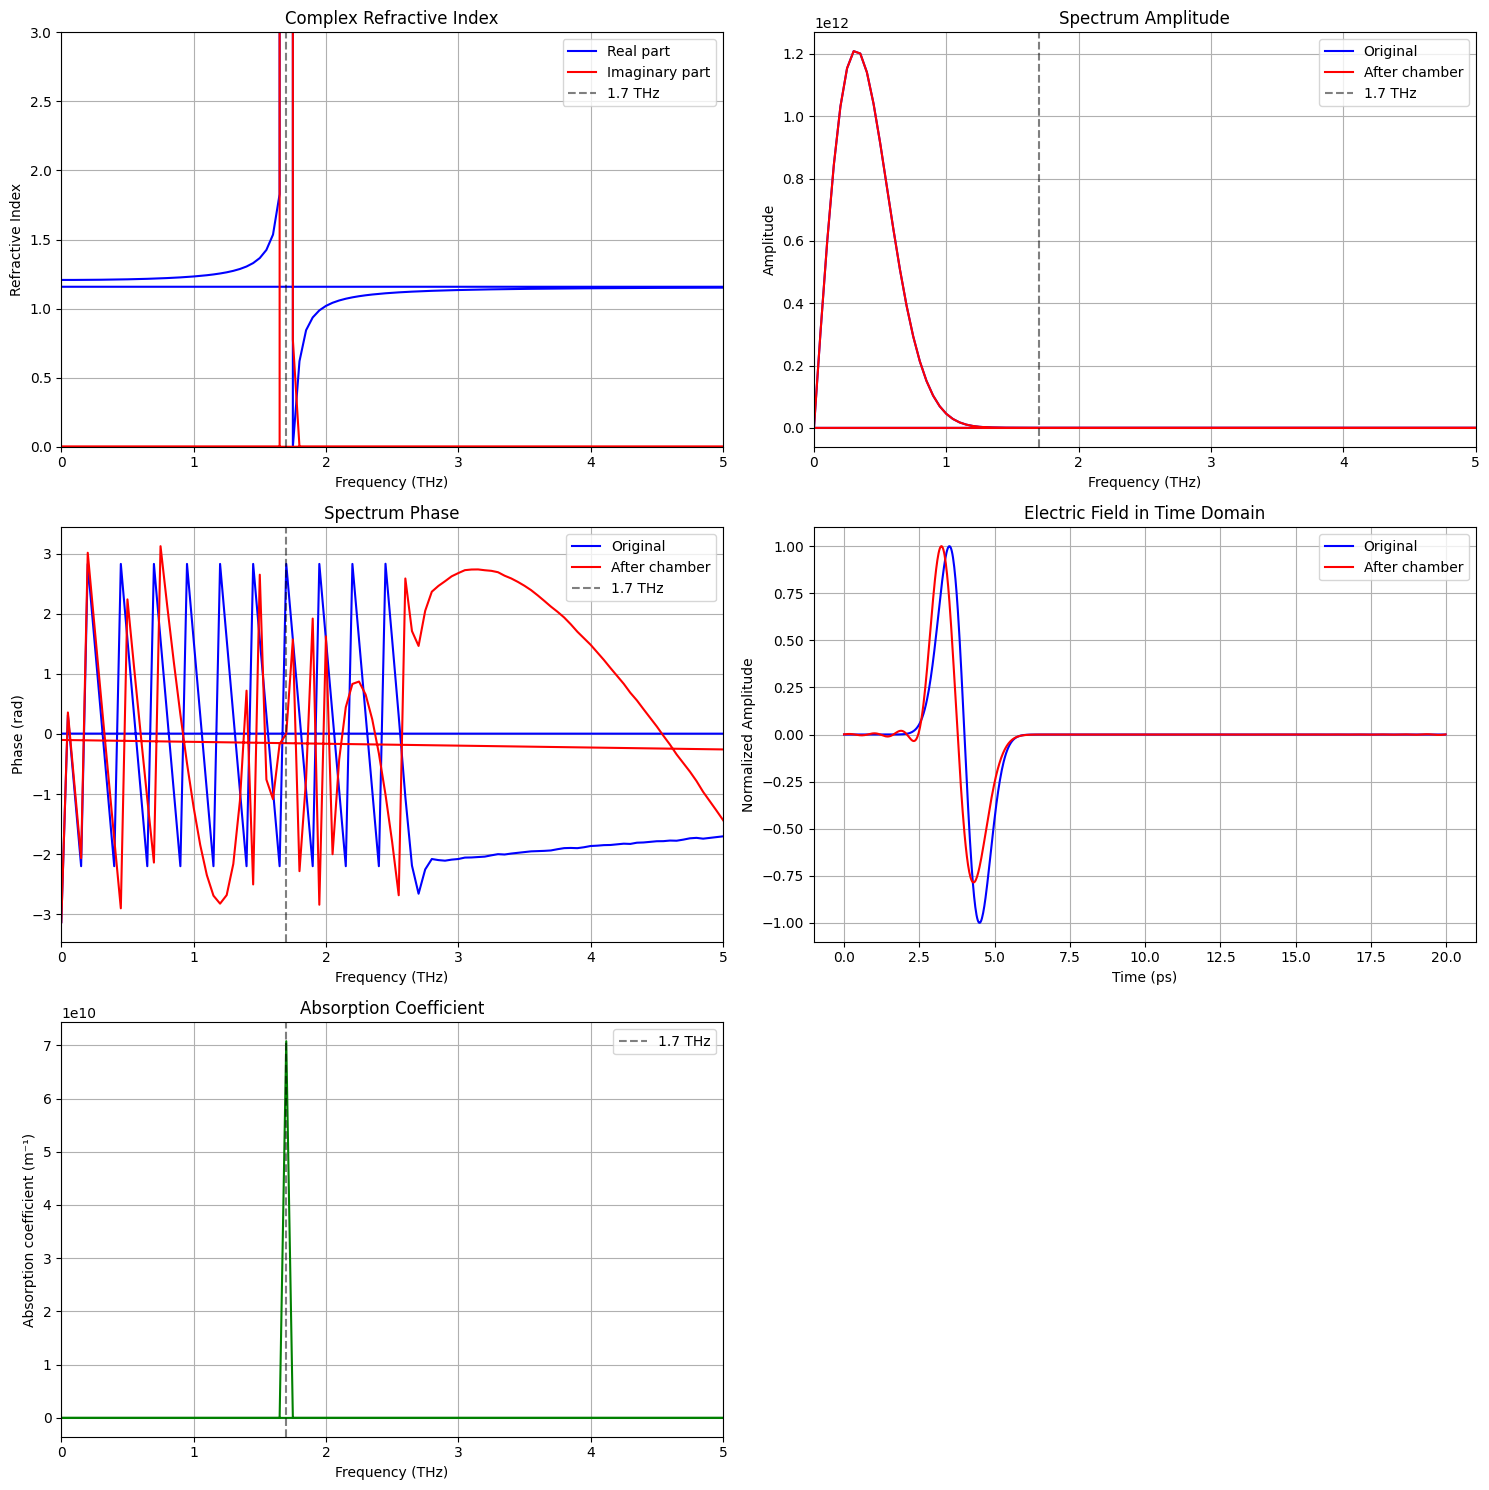

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift, ifftshift
from scipy.constants import c

# Parameters for the Gaussian current
b = 4e-12  # 4 ps
sigma = 0.5e-12  # 0.5 ps
a = 1/(sigma*np.sqrt(2*np.pi))

# Time domain parameters
dt = 0.02e-12  # 0.02 ps time step
t = np.arange(0, 20e-12, dt)  # 0 to 20 ps
N = len(t)
df = 1/(N*dt)  # Frequency step
f = np.arange(0, N)*df  # Frequency array
f = np.where(f > N*df/2, f-N*df, f)  # Shift to center at zero
f = fftshift(f)  # Shift to make frequencies centered
omega = 2*np.pi*f  # Angular frequency

# Create the Gaussian current
current = a * np.exp(-((t-b)**2)/(2*sigma**2))

# Calculate the electric field (proportional to derivative of current)
dcurrent_dt = -a * ((t-b)/(sigma**2)) * np.exp(-((t-b)**2)/(2*sigma**2))
E_field = dcurrent_dt  # Proportional to derivative

# Calculate the spectrum using FFT
E_spectrum = fftshift(fft(E_field)) * dt

# Parameters for the gas with absorption at 1.7 THz
eps_inf = np.sqrt(1.8)
gamma = 0.2 * np.pi
omega_p = 2*np.pi * 0.5e12  # 0.5 THz
omega_r = 2*np.pi * 1.7e12  # 1.7 THz
d = 5e-3  # 5 mm chamber length

# Calculate complex permittivity
eps_r = eps_inf * (1 + (omega_p**2)/(omega_r**2 - omega**2 - 1j*gamma*omega))

# Calculate complex refractive index
n_complex = np.sqrt(eps_r)
n_real = np.real(n_complex)
n_imag = np.imag(n_complex)

# Transfer function for propagation through the chamber
H = np.exp(1j * n_complex * omega * d / c)

# Modified spectrum after propagation
E_spectrum_modified = E_spectrum * H

# Inverse FFT to get time-domain pulse after propagation
E_field_modified = ifft(ifftshift(E_spectrum_modified)) / dt

# Plot the spectrum, phase, and refractive index
plt.figure(figsize=(15, 15))

# Plot 1: Real and imaginary parts of complex refractive index
plt.subplot(3, 2, 1)
plt.plot(f/1e12, n_real, 'b-', label='Real part')
plt.plot(f/1e12, n_imag, 'r-', label='Imaginary part')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.ylim(0, 3)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Refractive Index')
plt.title('Complex Refractive Index')
plt.legend()

# Plot 2: Original vs. Modified Spectrum Amplitude
plt.subplot(3, 2, 2)
plt.plot(f/1e12, np.abs(E_spectrum), 'b-', label='Original')
plt.plot(f/1e12, np.abs(E_spectrum_modified), 'r-', label='After chamber')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Amplitude')
plt.title('Spectrum Amplitude')
plt.legend()

# Plot 3: Original vs. Modified Phase
plt.subplot(3, 2, 3)
plt.plot(f/1e12, np.angle(E_spectrum), 'b-', label='Original')
plt.plot(f/1e12, np.angle(E_spectrum_modified), 'r-', label='After chamber')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Phase (rad)')
plt.title('Spectrum Phase')
plt.legend()

# Plot 4: Time-domain pulses
plt.subplot(3, 2, 4)
plt.plot(t/1e-12, E_field/np.max(E_field), 'b-', label='Original')
plt.plot(t/1e-12, np.real(E_field_modified)/np.max(np.real(E_field_modified)), 'r-', label='After chamber')
plt.grid(True)
plt.xlabel('Time (ps)')
plt.ylabel('Normalized Amplitude')
plt.title('Electric Field in Time Domain')
plt.legend()

# Plot 5: Absorption coefficient
alpha = 2 * omega * n_imag / c
plt.subplot(3, 2, 5)
plt.plot(f/1e12, alpha, 'g-')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Absorption coefficient (m⁻¹)')
plt.title('Absorption Coefficient')
plt.legend()

# Adjust layout and show
plt.tight_layout()
plt.show()

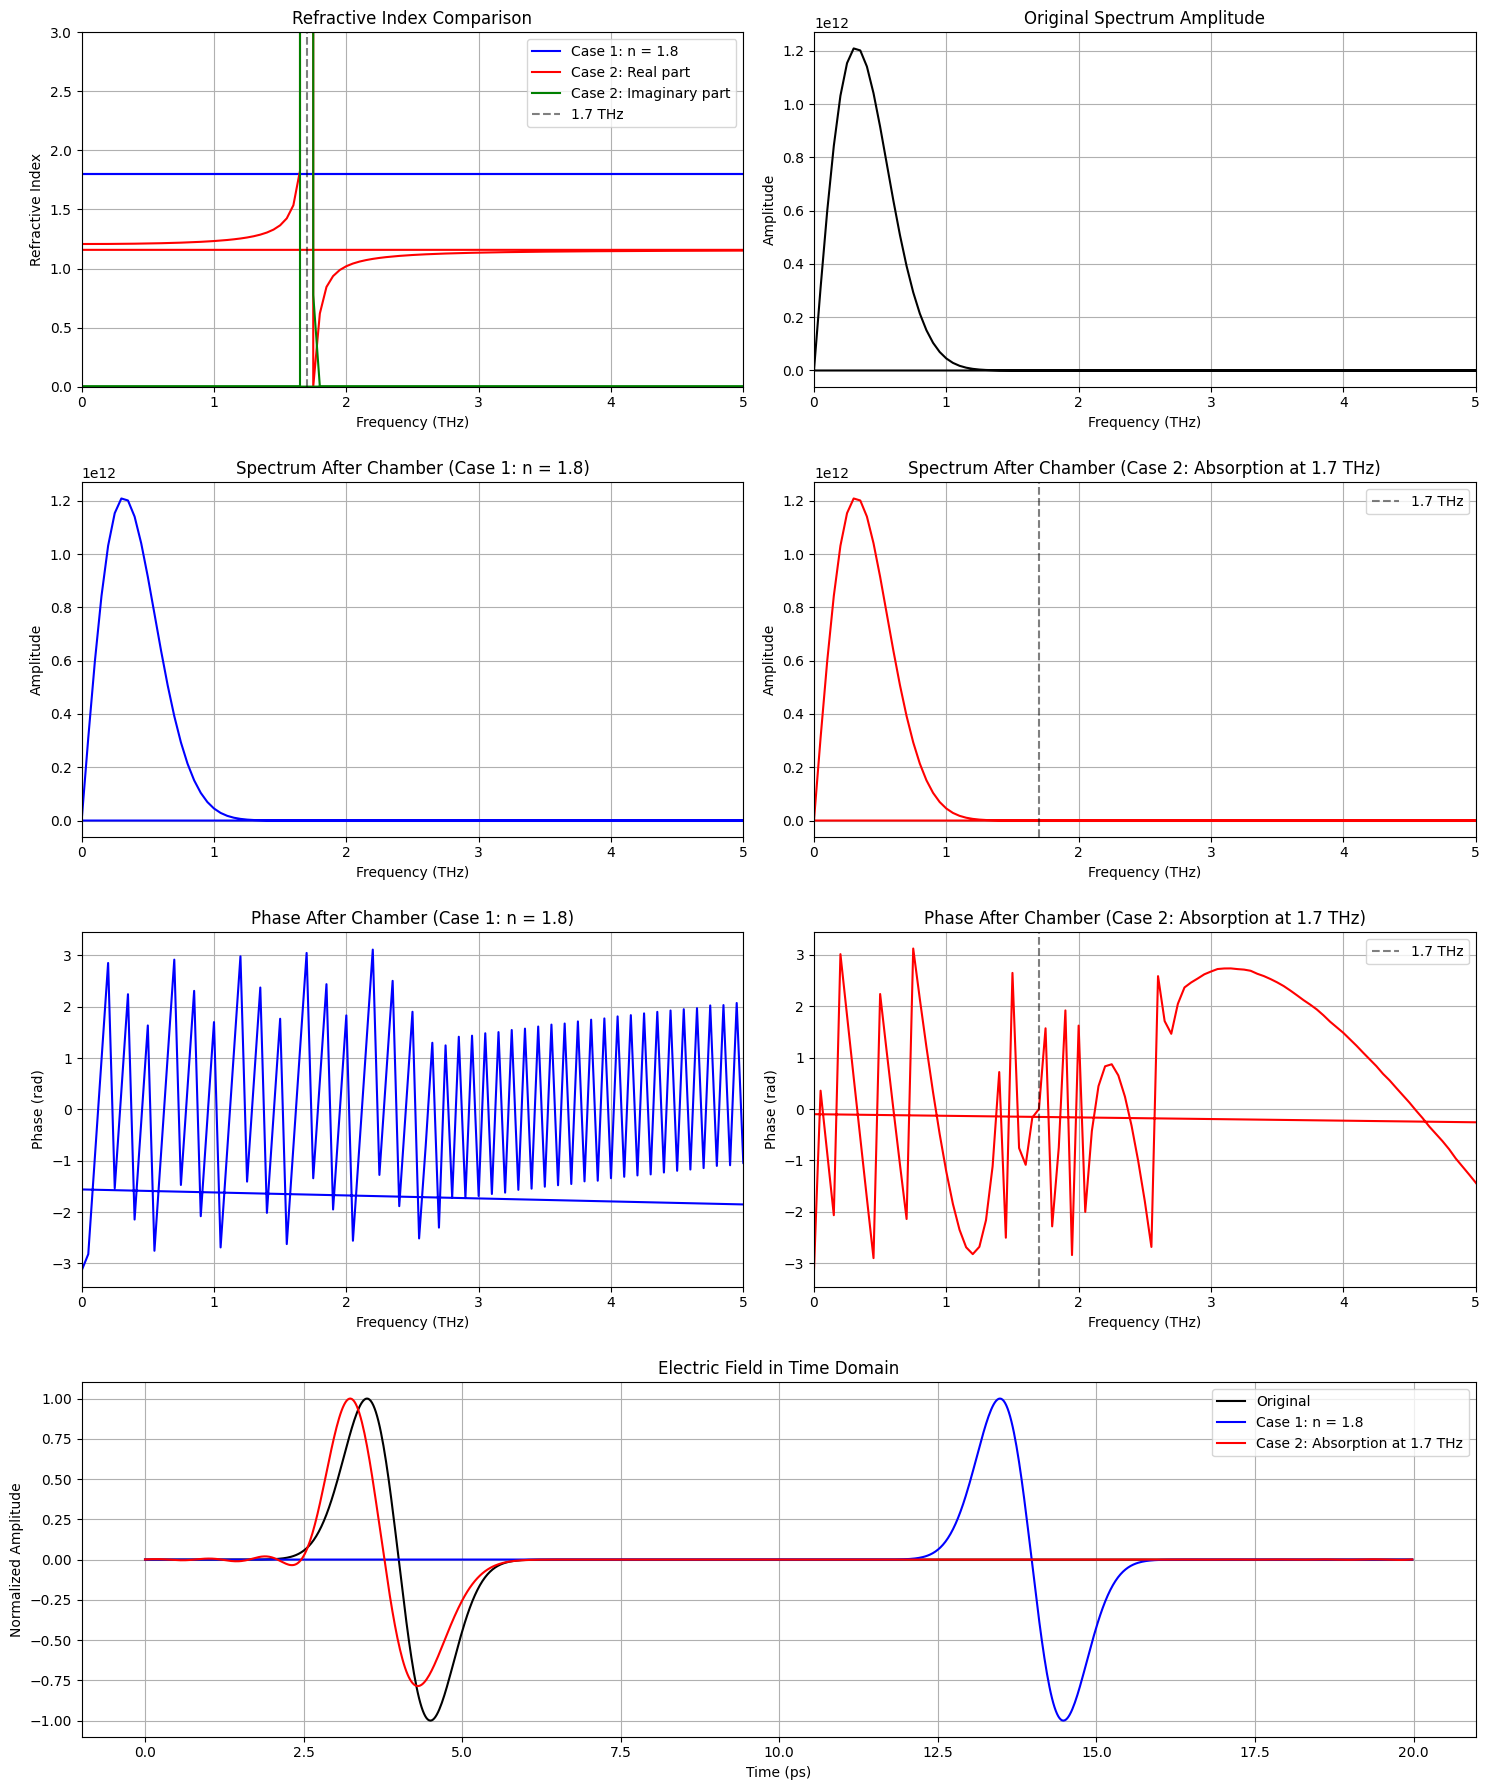

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft, ifft, fftshift, ifftshift
from scipy.constants import c

# Parameters for the Gaussian current
b = 4e-12  # 4 ps
sigma = 0.5e-12  # 0.5 ps
a = 1/(sigma*np.sqrt(2*np.pi))

# Time domain parameters
dt = 0.02e-12  # 0.02 ps time step
t = np.arange(0, 20e-12, dt)  # 0 to 20 ps
N = len(t)
df = 1/(N*dt)  # Frequency step
f = np.arange(0, N)*df  # Frequency array
f = np.where(f > N*df/2, f-N*df, f)  # Shift to center at zero
f = fftshift(f)  # Shift to make frequencies centered
omega = 2*np.pi*f  # Angular frequency

# Create the Gaussian current
current = a * np.exp(-((t-b)**2)/(2*sigma**2))

# Calculate the electric field (proportional to derivative of current)
dcurrent_dt = -a * ((t-b)/(sigma**2)) * np.exp(-((t-b)**2)/(2*sigma**2))
E_field = dcurrent_dt  # Proportional to derivative

# Calculate the spectrum using FFT
E_spectrum = fftshift(fft(E_field)) * dt

# Parameters for chamber
d = 5e-3  # 5 mm chamber length

# CASE 1: Constant refractive index n = 1.8
n_constant = 1.8
H_constant = np.exp(1j * n_constant * omega * d / c)
E_spectrum_case1 = E_spectrum * H_constant
E_field_case1 = ifft(ifftshift(E_spectrum_case1)) / dt

# CASE 2: Gas with absorption at 1.7 THz
eps_inf = np.sqrt(1.8)
gamma = 0.2 * np.pi
omega_p = 2*np.pi * 0.5e12  # 0.5 THz
omega_r = 2*np.pi * 1.7e12  # 1.7 THz

# Calculate complex permittivity
eps_r = eps_inf * (1 + (omega_p**2)/(omega_r**2 - omega**2 - 1j*gamma*omega))

# Calculate complex refractive index
n_complex = np.sqrt(eps_r)
n_real = np.real(n_complex)
n_imag = np.imag(n_complex)

# Transfer function for propagation through the chamber with absorption
H_absorption = np.exp(1j * n_complex * omega * d / c)

# Modified spectrum after propagation with absorption
E_spectrum_case2 = E_spectrum * H_absorption

# Inverse FFT to get time-domain pulse after propagation
E_field_case2 = ifft(ifftshift(E_spectrum_case2)) / dt

# Plot the results for both cases
plt.figure(figsize=(15, 18))

# Plot 1: Refractive Index Comparison
plt.subplot(4, 2, 1)
plt.plot(f/1e12, np.ones_like(f) * n_constant, 'b-', label='Case 1: n = 1.8')
plt.plot(f/1e12, n_real, 'r-', label='Case 2: Real part')
plt.plot(f/1e12, n_imag, 'g-', label='Case 2: Imaginary part')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.ylim(0, 3)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Refractive Index')
plt.title('Refractive Index Comparison')
plt.legend()

# Plot 2: Original Spectrum Amplitude
plt.subplot(4, 2, 2)
plt.plot(f/1e12, np.abs(E_spectrum), 'k-')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Amplitude')
plt.title('Original Spectrum Amplitude')

# Plot 3: Spectrum Amplitude - Case 1 (n = 1.8)
plt.subplot(4, 2, 3)
plt.plot(f/1e12, np.abs(E_spectrum_case1), 'b-')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Amplitude')
plt.title('Spectrum After Chamber (Case 1: n = 1.8)')

# Plot 4: Spectrum Amplitude - Case 2 (Absorption)
plt.subplot(4, 2, 4)
plt.plot(f/1e12, np.abs(E_spectrum_case2), 'r-')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Amplitude')
plt.title('Spectrum After Chamber (Case 2: Absorption at 1.7 THz)')
plt.legend()

# Plot 5: Phase - Case 1 (n = 1.8)
plt.subplot(4, 2, 5)
plt.plot(f/1e12, np.angle(E_spectrum_case1), 'b-')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Phase (rad)')
plt.title('Phase After Chamber (Case 1: n = 1.8)')

# Plot 6: Phase - Case 2 (Absorption)
plt.subplot(4, 2, 6)
plt.plot(f/1e12, np.angle(E_spectrum_case2), 'r-')
plt.axvline(x=1.7, color='k', linestyle='--', alpha=0.5, label='1.7 THz')
plt.xlim(0, 5)
plt.grid(True)
plt.xlabel('Frequency (THz)')
plt.ylabel('Phase (rad)')
plt.title('Phase After Chamber (Case 2: Absorption at 1.7 THz)')
plt.legend()

# Plot 7: Time-domain Comparison
plt.subplot(4, 1, 4)
plt.plot(t/1e-12, E_field/np.max(np.abs(E_field)), 'k-', label='Original')
plt.plot(t/1e-12, np.real(E_field_case1)/np.max(np.abs(E_field_case1)), 'b-', label='Case 1: n = 1.8')
plt.plot(t/1e-12, np.real(E_field_case2)/np.max(np.abs(E_field_case2)), 'r-', label='Case 2: Absorption at 1.7 THz')
plt.grid(True)
plt.xlabel('Time (ps)')
plt.ylabel('Normalized Amplitude')
plt.title('Electric Field in Time Domain')
plt.legend()

# Adjust layout and show
plt.tight_layout()
plt.show()

In [7]:
print(select_neighbours(3, 67, 30, 30))

[36, 37, 38, 66, 67, 68, 96, 97, 98]


In [4]:
def visualize_neighbors(size, center, dim_axis_0, dim_axis_1):
    """
    Visualizes a grid and highlights the neighbors selected by select_neighbours function.
    
    Parameters
    ----------
    size : int
        The size of the kernel.
    center : int
        The center element index.
    dim_axis_0 : int
        The number of elements in axis 0 (rows).
    dim_axis_1 : int
        The number of elements in axis 1 (columns).
    """
    # Get the neighbors using the select_neighbours function
    neighbors = select_neighbours(size, center, dim_axis_0, dim_axis_1)
    
    # Convert center index to 2D coordinates
    center_row = center // dim_axis_1
    center_col = center % dim_axis_1
    
    # Create the visualization
    print(f"Grid: {dim_axis_0}x{dim_axis_1}")
    print(f"Center: index {center} (row {center_row}, col {center_col})")
    print(f"Kernel size: {size}x{size}")
    print(f"Neighbors: {neighbors}")
    print("\nGrid Visualization:")
    
    # Header row with column numbers
    print("   ", end="")
    for j in range(dim_axis_1):
        print(f"{j:2d} ", end="")
    print()
    
    # Separator
    print("   " + "-" * (dim_axis_1 * 3))
    
    # Grid with row numbers
    for i in range(dim_axis_0):
        print(f"{i:2d}|", end="")
        for j in range(dim_axis_1):
            index = i * dim_axis_1 + j
            if index == center:
                print(" C ", end="")  # Center
            elif index in neighbors:
                print(" # ", end="")  # Neighbor
            else:
                print(" . ", end="")  # Non-neighbor
        print()
    
    print("\nLegend:")
    print("C - Center element")
    print("# - Neighbor element")
    print(". - Non-neighbor element")


# Example usage:
def example_visualization():
    print("Example 1: 3x3 kernel in a 5x5 grid, center at (2,2)")
    visualize_neighbors(3, 12, 5, 5)
    
    print("\nExample 2: 5x5 kernel in a 7x7 grid, center at (3,3)")
    visualize_neighbors(5, 24, 7, 7)
    
    print("\nExample 3: 3x3 kernel near edge, center at (0,0)")
    visualize_neighbors(3, 0, 5, 5)
    
    print("\nExample 4: 7x7 kernel in a 6x6 grid (kernel gets clipped), center at (2,3)")
    visualize_neighbors(7, 15, 6, 6)

# Uncomment the following line to run the examples
example_visualization()

Example 1: 3x3 kernel in a 5x5 grid, center at (2,2)
Grid: 5x5
Center: index 12 (row 2, col 2)
Kernel size: 3x3
Neighbors: [6, 7, 8, 11, 12, 13, 16, 17, 18]

Grid Visualization:
    0  1  2  3  4 
   ---------------
 0| .  .  .  .  . 
 1| .  #  #  #  . 
 2| .  #  C  #  . 
 3| .  #  #  #  . 
 4| .  .  .  .  . 

Legend:
C - Center element
# - Neighbor element
. - Non-neighbor element

Example 2: 5x5 kernel in a 7x7 grid, center at (3,3)
Grid: 7x7
Center: index 24 (row 3, col 3)
Kernel size: 5x5
Neighbors: [8, 9, 10, 11, 12, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26, 29, 30, 31, 32, 33, 36, 37, 38, 39, 40]

Grid Visualization:
    0  1  2  3  4  5  6 
   ---------------------
 0| .  .  .  .  .  .  . 
 1| .  #  #  #  #  #  . 
 2| .  #  #  #  #  #  . 
 3| .  #  #  C  #  #  . 
 4| .  #  #  #  #  #  . 
 5| .  #  #  #  #  #  . 
 6| .  .  .  .  .  .  . 

Legend:
C - Center element
# - Neighbor element
. - Non-neighbor element

Example 3: 3x3 kernel near edge, center at (0,0)
Grid: 5x5
Center: inde

In [2]:
import numpy as np
import scipy.integrate as integrate

# Constants
h = 6.626e-34  # Planck's constant
c = 3e8        # Speed of light
k = 1.38e-23   # Boltzmann constant

def planck_radiance(v, T):
    """Calculate spectral radiance using Planck's law"""
    numerator = 2 * h * (v**3) / (c**2)
    exponent = (h * v) / (k * T)
    denominator = np.exp(exponent) - 1
    return numerator / denominator

def integration_func(v, sigma, omega, T):
    """Function to integrate"""
    return planck_radiance(v, T) * sigma * omega

# Parameters
T1 = 300  # Kelvin
T2 = 77   # Kelvin

# Detector and blackbody parameters
D = 0.05    # Blackbody diameter
d = 0.0001  # Detector diameter
L = 0.3     # Distance

# Calculate cross-sectional area (sigma)
sigma = np.pi * (d/2)**2
print(sigma)
# Calculate solid angle
omega = np.pi * (d/2)**2 / (L**2)
print(omega)
# Integrate over frequency
def integrand_v(v):
    return integration_func(v, sigma, omega, T1)

# Numerical integration
result_T1, error_T1 = integrate.quad(integrand_v, 1.45e12, 1.55e12)
print(f"Integrated Spectral Radiance at 300K: {result_T1:.4e} W")

def integrand_v_T2(v):
    return integration_func(v, sigma, omega, T2)

result_T2, error_T2 = integrate.quad(integrand_v_T2, 1.45e12, 1.55e12)
print(f"Integrated Spectral Radiance at 77K: {result_T2:.4e} W")

7.853981633974483e-09
8.726646259971648e-08
Integrated Spectral Radiance at 300K: 1.2556e-17 W
Integrated Spectral Radiance at 77K: 2.2002e-18 W


In [8]:
## Testing python logic
import numpy as np
status = np.ones(10) * 10
# Generate arrays with random numbers to determine if there is afterpulsing and/or crosstalk.
enable_deadtime = False
pixel_number = 4
timestamp = 5
if not enable_deadtime or status[pixel_number] < timestamp:
    print(f"Enable_deadtime: {enable_deadtime}, status: {status[pixel_number]}, timestamp: {timestamp}")
    print("No deadtime or status is less than timestamp")
else:
    print("Deadtime is enabled and status is greater than timestamp")

Enable_deadtime: False, status: 10.0, timestamp: 5
No deadtime or status is less than timestamp


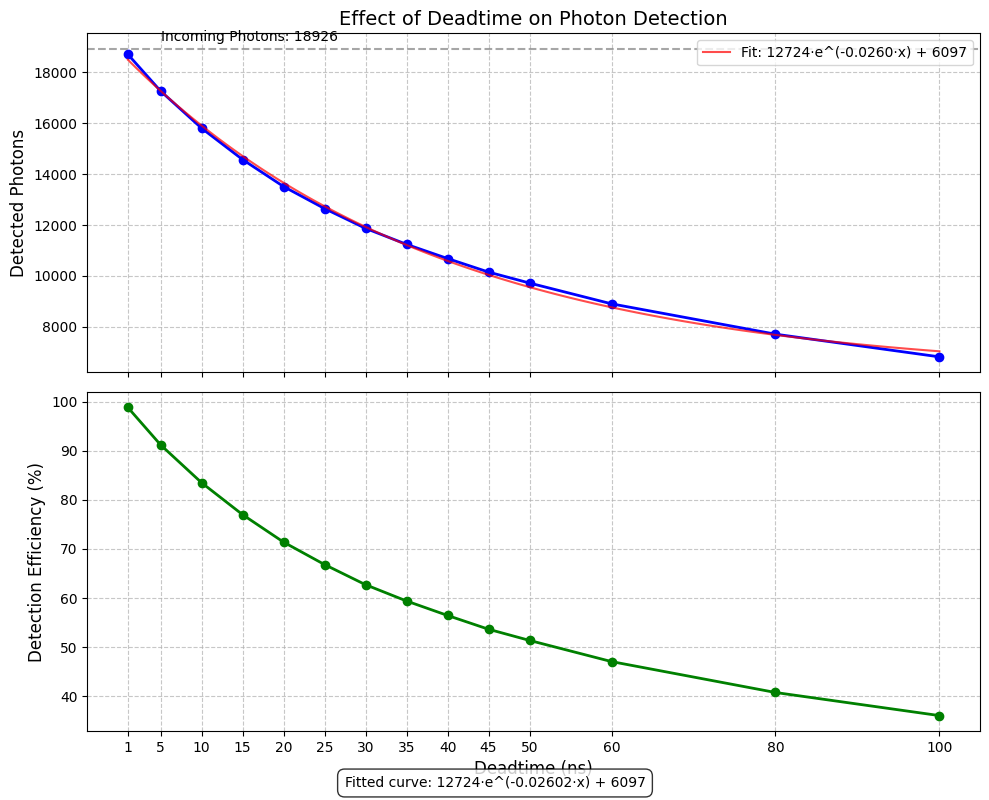

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
deadtime = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 80, 100]
detected_photons = [18706, 17262, 15803, 14572, 13512, 12647, 11870, 11242, 10685, 10153, 9722, 8906, 7714, 6823]
incoming_photons = 18926

# Calculate detection efficiency as percentage
detection_efficiency = [100 * detected / incoming_photons for detected in detected_photons]

# Create figure with two subplots sharing x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.1)  # Reduce space between plots

# Plot 1: Detected Photons vs Deadtime
ax1.plot(deadtime, detected_photons, 'o-', color='blue', markersize=6, linewidth=2)
ax1.set_ylabel('Detected Photons', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_title('Effect of Deadtime on Photon Detection', fontsize=14)
ax1.tick_params(axis='both', which='major', labelsize=10)

# Add incoming photons reference line
ax1.axhline(y=incoming_photons, color='gray', linestyle='--', alpha=0.7)
ax1.text(5, incoming_photons + 200, f'Incoming Photons: {incoming_photons}', 
         fontsize=10, verticalalignment='bottom')

# Plot 2: Detection Efficiency vs Deadtime
ax2.plot(deadtime, detection_efficiency, 'o-', color='green', markersize=6, linewidth=2)
ax2.set_xlabel('Deadtime (ns)', fontsize=12)
ax2.set_ylabel('Detected (%)', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.tick_params(axis='both', which='major', labelsize=10)

# Set x-axis to show all data points
plt.xticks(deadtime)

# Fitting an exponential decay curve to the data
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

from scipy.optimize import curve_fit
params, _ = curve_fit(exp_decay, deadtime, detected_photons, 
                       p0=[incoming_photons, 0.01, 0])

x_smooth = np.linspace(min(deadtime), max(deadtime), 100)
y_fit = exp_decay(x_smooth, *params)

# Add fitted curve to the first plot
ax1.plot(x_smooth, y_fit, 'r-', linewidth=1.5, alpha=0.7, 
         label=f'Fit: {params[0]:.0f}·e^(-{params[1]:.4f}·x) + {params[2]:.0f}')
ax1.legend(loc='upper right', fontsize=10)

# Annotations
fit_equation = f"Fitted curve: {params[0]:.0f}·e^(-{params[1]:.5f}·x) + {params[2]:.0f}"
plt.figtext(0.5, 0.01, fit_equation, ha='center', fontsize=10, 
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)  # Make room for the equation at the bottom
plt.savefig('deadtime_photon_detection.png', dpi=300, bbox_inches='tight')
plt.show()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


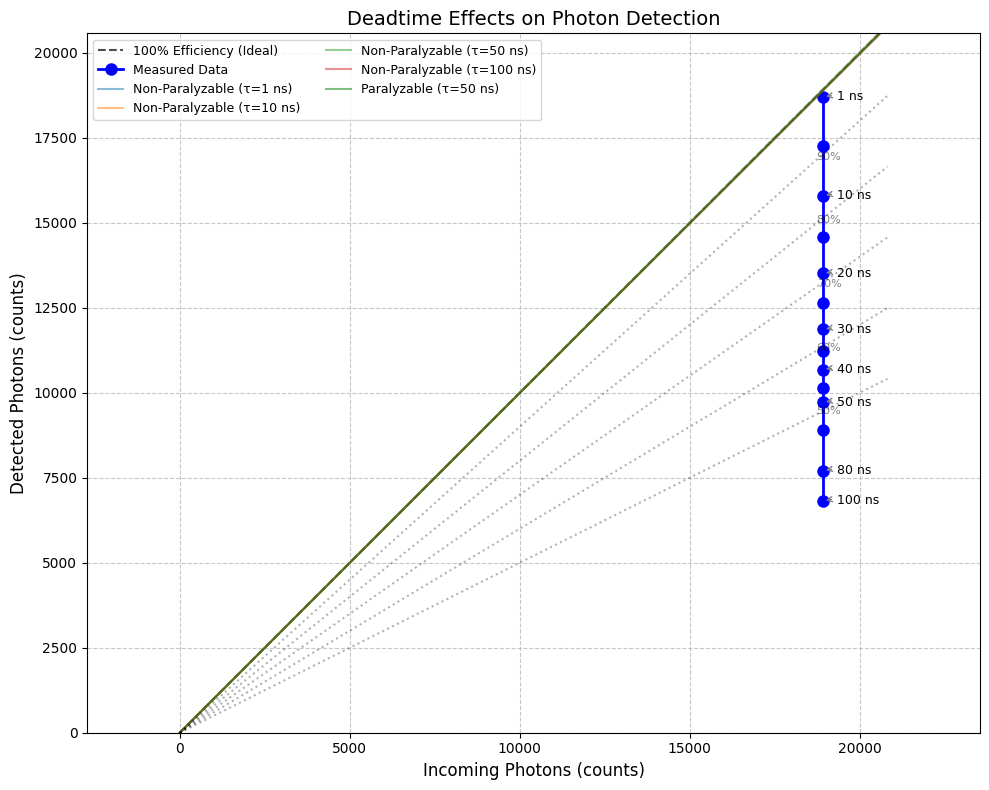

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Data
deadtime_values = [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 80, 100]  # in ns
detected_photons = [18706, 17262, 15803, 14572, 13512, 12647, 11870, 11242, 10685, 10153, 9722, 8906, 7714, 6823]
incoming_photon_count = 18926

# Create figure
plt.figure(figsize=(10, 8))

# Create the 100% efficiency diagonal line (ideal detector)
max_value = incoming_photon_count * 1.1  # Extend a bit beyond the data
diagonal_line = np.linspace(0, max_value, 100)
plt.plot(diagonal_line, diagonal_line, 'k--', alpha=0.7, label='100% Efficiency (Ideal)')

# Plot the actual data as a vertical line with deadtime as the parameter
plt.plot([incoming_photon_count] * len(detected_photons), detected_photons, 'o-', 
         color='blue', markersize=8, linewidth=2, label='Measured Data')

# Add deadtime annotations to selected points
for i, (y, dt) in enumerate(zip(detected_photons, deadtime_values)):
    if i % 2 == 0 or dt == 100:  # Annotate every other point and the last point
        plt.annotate(f"{dt} ns", 
                     xy=(incoming_photon_count, y),
                     xytext=(10, 0), 
                     textcoords="offset points",
                     va='center', 
                     fontsize=9, 
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.1', color='gray'))

# Calculate the non-paralyzable deadtime model curve
# N_out = N_in / (1 + N_in * tau), where tau is deadtime in seconds
n_in_range = np.linspace(0, incoming_photon_count * 1.1, 1000)
tau_values_for_curves = [1e-9, 10e-9, 50e-9, 100e-9]  # 1, 10, 50, 100 ns

for tau in tau_values_for_curves:
    n_out = n_in_range / (1 + n_in_range * tau)
    plt.plot(n_in_range, n_out, '-', alpha=0.5, 
             label=f'Non-Paralyzable (τ={int(tau*1e9)} ns)')

# Add paralyzable model for comparison
# N_out = N_in * exp(-N_in * tau)
tau_for_paralyzable = 50e-9  # 50 ns
n_out_paralyzable = n_in_range * np.exp(-n_in_range * tau_for_paralyzable)
plt.plot(n_in_range, n_out_paralyzable, 'g-', alpha=0.5, 
         label=f'Paralyzable (τ=50 ns)')

# Set labels and title
plt.xlabel('Incoming Photons (counts)', fontsize=12)
plt.ylabel('Detected Photons (counts)', fontsize=12)
plt.title('Deadtime Effects on Photon Detection', fontsize=14)

# Set equal scaling for x and y axes
plt.axis('equal')

# Set reasonable axis limits
plt.xlim(0, incoming_photon_count * 1.1)
plt.ylim(0, max(detected_photons) * 1.1)

# Add grid
plt.grid(True, linestyle='--', alpha=0.7)

# Add efficiency lines at 90%, 80%, etc.
efficiencies = [0.9, 0.8, 0.7, 0.6, 0.5]
for eff in efficiencies:
    x_vals = np.linspace(0, max_value, 100)
    y_vals = x_vals * eff
    plt.plot(x_vals, y_vals, 'k:', alpha=0.3)
    plt.text(max_value * 0.9, max_value * 0.9 * eff, f"{eff*100:.0f}%", 
             fontsize=8, alpha=0.5)

# Add legend with smaller font and more columns
plt.legend(loc='upper left', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('deadtime_plot_switched_axes.png', dpi=300, bbox_inches='tight')
plt.show()

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_neighbors_plt(size, center, dim_axis_0, dim_axis_1):
    """
    Visualizes a grid and highlights the neighbors selected by select_neighbours function using matplotlib.
    
    Parameters
    ----------
    size : int
        The size of the kernel.
    center : int
        The center element index.
    dim_axis_0 : int
        The number of elements in axis 0 (rows).
    dim_axis_1 : int
        The number of elements in axis 1 (columns).
    """
    # Get the neighbors using the select_neighbours function
    neighbors = select_neighbours(size, center, dim_axis_0, dim_axis_1)
    
    # Convert center index to 2D coordinates
    center_row = center // dim_axis_1
    center_col = center % dim_axis_1
    
    # Create a grid to visualize
    grid = np.zeros((dim_axis_0, dim_axis_1))
    
    # Mark neighbors as 1
    for idx in neighbors:
        row = idx // dim_axis_1
        col = idx % dim_axis_1
        grid[row, col] = 1
    
    # Mark center as 2
    grid[center_row, center_col] = 2
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Create a colormap: white for non-neighbors, light blue for neighbors, dark blue for center
    cmap = plt.cm.colors.ListedColormap(['white', 'lightblue', 'darkblue'])
    bounds = [-0.5, 0.5, 1.5, 2.5]
    norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)
    
    # Create the heatmap
    im = ax.imshow(grid, cmap=cmap, norm=norm)
    
    # Add grid lines
    ax.grid(True, which='both', color='black', linewidth=0.5)
    ax.set_xticks(np.arange(-0.5, dim_axis_1, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, dim_axis_0, 1), minor=True)
    ax.set_xticks(np.arange(0, dim_axis_1, 1))
    ax.set_yticks(np.arange(0, dim_axis_0, 1))
    
    # Add index numbers to cells
    for i in range(dim_axis_0):
        for j in range(dim_axis_1):
            idx = i * dim_axis_1 + j
            text_color = 'white' if idx == center else 'black'
            ax.text(j, i, f"{idx}", ha="center", va="center", color=text_color, fontsize=9)
    
    # Customize axis ticks
    ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False)
    ax.set_xticklabels([f"{i}" for i in range(dim_axis_1)], fontsize=9)
    ax.set_yticklabels([f"{i}" for i in range(dim_axis_0)], fontsize=9)
    
    # Add title and labels
    plt.title(f"Grid {dim_axis_0}x{dim_axis_1}, Kernel {size}x{size}, Center: {center} (row {center_row}, col {center_col})")
    plt.xlabel("Column")
    plt.ylabel("Row")
    
    # Add legend patches
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='white', edgecolor='black', label='Non-neighbor'),
        Patch(facecolor='lightblue', edgecolor='black', label='Neighbor'),
        Patch(facecolor='darkblue', edgecolor='black', label='Center')
    ]
    ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=3)
    
    # Adjust layout to make room for the legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    
    return plt

# Example usage:
def example_visualization_plt():
    # Example 1: 3x3 kernel in a 5x5 grid, center at (2,2) (index 12)
    plt1 = visualize_neighbors_plt(3, 12, 5, 5)
    plt1.savefig('example1.png')
    plt1.close()
    
    # Example 2: 5x5 kernel in a 7x7 grid, center at (3,3) (index 24)
    plt2 = visualize_neighbors_plt(5, 24, 7, 7)
    plt2.savefig('example2.png')
    plt2.close()
    
    # Example 3: 3x3 kernel near edge, center at (0,0) (index 0)
    plt3 = visualize_neighbors_plt(3, 0, 5, 5)
    plt3.savefig('example3.png')
    plt3.close()
    
    # Example 4: 7x7 kernel in a 6x6 grid (kernel gets clipped), center at (2,3) (index 15)
    plt4 = visualize_neighbors_plt(7, 15, 6, 6)
    plt4.savefig('example4.png')
    plt4.close()

# Uncomment to run examples
example_visualization_plt()

# To use the function with specific parameters:
# visualize_neighbors_plt(kernel_size, center_index, grid_rows, grid_cols)

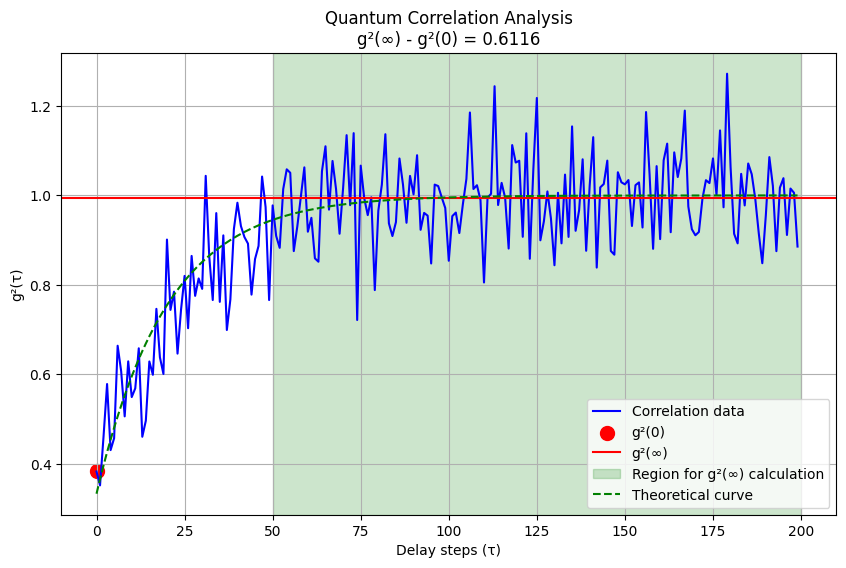

g²(0): 0.3830
g²(∞): 0.9946
Difference: 0.6116


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def generate_correlation_data(n_points=200, n=1.5, k=0.05, noise_level=0.1):
    """
    Generate correlation data based on the formula: 1 - (1/n) * exp(-k*tau)
    
    Parameters:
    n_points : int
        Number of points to generate
    n : float
        Parameter controlling the amplitude of the exponential term
    k : float
        Decay/rise rate constant
    noise_level : float
        Amount of random noise to add
        
    Returns:
    numpy array: Generated correlation data
    """
    tau = np.arange(n_points)
    # Generate the clean data based on the formula
    data = 1 - (1/n) * np.exp(-k * tau)
    
    # Add some random noise to simulate real measurements
    noise = noise_level * np.random.randn(n_points)
    noisy_data = data + noise
    
    return noisy_data

def calculate_g2_difference(correlation_data, start_index=0, tau_min=50, tau_max=None):
    """
    Calculate the difference between g²(0) and g²(∞) for quantum correlation data.
    """
    # Get g²(0)
    g2_zero = correlation_data[start_index]
    
    # Set tau_max if not provided
    if tau_max is None:
        tau_max = len(correlation_data)
    
    # Calculate g²(∞) by averaging over delay values [tau_min, tau_max]
    g2_inf = np.mean(correlation_data[tau_min:tau_max])
    
    # Calculate the difference
    g2_difference =  g2_inf - g2_zero
    
    return {
        "g2_zero": g2_zero,
        "g2_infinity": g2_inf,
        "difference": g2_difference
    }

def visualize_g2_calculation(correlation_data, result, start_index=0, tau_min=50, tau_max=None):
    """
    Visualize the correlation data and g² calculations.
    """
    if tau_max is None:
        tau_max = len(correlation_data)
    
    plt.figure(figsize=(10, 6))
    
    # Plot the correlation data
    plt.plot(correlation_data, 'b-', label='Correlation data')
    
    # Mark g²(0)
    plt.scatter(start_index, correlation_data[start_index], color='red', s=100, label='g²(0)')
    
    # Highlight the region used for g²(∞)
    plt.axhline(y=result["g2_infinity"], color='red', linestyle='-', label='g²(∞)')
    plt.axvspan(tau_min, tau_max, alpha=0.2, color='green', label='Region for g²(∞) calculation')
    
    # Plot the theoretical curve
    tau = np.arange(len(correlation_data))
    theoretical = 1 - (1/1.5) * np.exp(-0.05 * tau)
    plt.plot(tau, theoretical, 'g--', label='Theoretical curve')
    
    plt.title(f'Quantum Correlation Analysis\ng²(∞) - g²(0) = {result["difference"]:.4f}')
    plt.xlabel('Delay steps (τ)')
    plt.ylabel('g²(τ)')
    plt.legend()
    plt.grid(True)
    
    return plt

# Generate correlation data
np.random.seed(42)  # For reproducibility
correlation_data = generate_correlation_data(n_points=200, n=1.5, k=0.05, noise_level=0.1)

# Calculate the g2 difference
result = calculate_g2_difference(correlation_data, start_index=0, tau_min=50)

# Visualize the results
vis = visualize_g2_calculation(correlation_data, result, start_index=0, tau_min=50)
plt.show()

# Print the results
print(f"g²(0): {result['g2_zero']:.4f}")
print(f"g²(∞): {result['g2_infinity']:.4f}")
print(f"Difference: {result['difference']:.4f}")